Exploratory Data Analysis on diabetes patients dataset

*This file has been thought to be a precise hand-on exercise, without focusing on obtaining high performances*

* Objective: to understand whether it is possible to predict glycated hemoglobin starting from some medical parameters
* Target variable: glyhb
* Feature: cholesterole, age, gender, height, weight, frame, blood pressure, waist and hip



In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [61]:
import os

# -----------------------------------------------------
# comment if using on local instead of Google Drive:
if os.path.exists("/content/drive/MyDrive"):
  print("drive is already mounted")
else:
  print("Drive is not yet mounted")
  from google.colab import drive
  drive.mount('/content/drive')
# -----------------------------------------------------

# change with your own directory
os.chdir('/content/drive/MyDrive/Colab Notebooks/diabetes_MachineLearning_project')

drive is already mounted


In [62]:
# change with your own directory
folder = "/content/drive/MyDrive/Colab Notebooks/diabetes_MachineLearning_project/"

dataFrameName = folder + "data/diabetes_1.csv"
dataframe = pd.read_csv(dataFrameName , index_col = 'id')

In [63]:
dataframe.head(10)

,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
id,,,,,,,,,,,,,,,,,,
1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0
1008,248.0,94,69.0,3.6,4.81,Buckingham,34,male,71.0,190.0,large,132.0,86.0,NaN,NaN,36.0,42.0,195.0
1011,195.0,92,41.0,4.8,4.84,Buckingham,30,male,69.0,191.0,medium,161.0,112.0,161.0,112.0,46.0,49.0,720.0
1015,227.0,75,44.0,5.2,3.94,Buckingham,37,male,59.0,170.0,medium,NaN,NaN,NaN,NaN,34.0,39.0,1020.0
1016,177.0,87,49.0,3.6,4.84,Buckingham,45,male,69.0,166.0,large,160.0,80.0,128.0,86.0,34.0,40.0,300.0


In [64]:
print(dataframe.shape)
print(dataframe.columns)

(403, 18)
Index(['chol', 'stab.glu', 'hdl', 'ratio', 'glyhb', 'location', 'age',
       'gender', 'height', 'weight', 'frame', 'bp.1s', 'bp.1d', 'bp.2s',
       'bp.2d', 'waist', 'hip', 'time.ppn'],
      dtype='object')


In [65]:
dataframe.describe()

,chol,stab.glu,hdl,ratio,glyhb,age,height,weight,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
count,402.000000,403.000000,402.000000,402.000000,390.000000,403.000000,398.000000,402.000000,398.000000,398.000000,141.000000,141.000000,401.000000,401.000000,400.000000
mean,207.845771,106.672457,50.445274,4.521642,5.589769,46.851117,66.020101,177.592040,136.904523,83.321608,152.382979,92.524823,37.900249,43.039900,341.250000
std,44.445557,53.076655,17.262626,1.727886,2.242595,16.312333,3.918515,40.340666,22.741033,13.589227,21.712952,11.555198,5.729313,5.656713,309.540953
min,78.000000,48.000000,12.000000,1.500000,2.680000,19.000000,52.000000,99.000000,90.000000,48.000000,110.000000,60.000000,26.000000,30.000000,5.000000
25%,179.000000,81.000000,38.000000,3.200000,4.380000,34.000000,63.000000,151.000000,121.250000,75.000000,138.000000,84.000000,33.000000,39.000000,90.000000
50%,204.000000,89.000000,46.000000,4.200000,4.840000,45.000000,66.000000,172.500000,136.000000,82.000000,149.000000,92.000000,37.000000,42.000000,240.000000
75%,230.000000,106.000000,59.000000,5.400000,5.600000,60.000000,69.000000,200.000000,146.750000,90.000000,161.000000,100.000000,41.000000,46.000000,517.500000
max,443.000000,385.000000,120.000000,19.299999,16.110001,92.000000,76.000000,325.000000,250.000000,124.000000,238.000000,124.000000,56.000000,64.000000,1560.000000


Correct units of measure and create new features:

In [66]:
dataframe["weight"] = dataframe["weight"]* 0.453592 # from pound to kg
dataframe["height"] = dataframe["height"]* 0.0254   # from foot to m

dataframe["waist"] = dataframe["waist"]* 0.0254 # from pound to kg
dataframe["hip"] = dataframe["hip"]* 0.0254   # from foot to m

In [67]:
#dataframe["bmi"] = dataframe["weight"]/(dataframe["height"]**2)

'''
dataframe["absi"] = dataframe["waist"]/ (
    (dataframe["weight"]/(dataframe["height"]**2))**(2/3) *
      (dataframe["height"])**(0.5)
    )

dataframe["map"] = (dataframe["bp.1s"]+2.0*dataframe["bp.1d"])/3.0 # Mean arterial pressure
'''

# this part should be analysed after performing the feature engineering on the train set

'\ndataframe["absi"] = dataframe["waist"]/ (\n    (dataframe["weight"]/(dataframe["height"]**2))**(2/3) *\n      (dataframe["height"])**(0.5)\n    )\n\ndataframe["map"] = (dataframe["bp.1s"]+2.0*dataframe["bp.1d"])/3.0 # Mean arterial pressure\n'

In [68]:
# I guess this feature should be ok. we are not "inventing" anything.
# We're just semplifying the age feature

dataframe["age_group"] = pd.cut(
    dataframe["age"],
    bins=[0, 30, 60, float("inf")],
    labels=["young", "middle", "old"],
    right=False
)

dataframe['frame'] = pd.Categorical(
    dataframe['frame'],
    categories=['small', 'medium', 'large'],
    ordered=True
)

In [69]:
dataframe.drop(columns=["location", "time.ppn"]).head(5)
# just to visualise the most relevant features

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,age_group
id,,,,,,,,,,,,,,,,,
1000,203.0,82,56.0,3.6,4.31,46,female,1.5748,54.884632,medium,118.0,59.0,NaN,NaN,0.7366,0.9652,middle
1001,165.0,97,24.0,6.9,4.44,29,female,1.6256,98.883056,large,112.0,68.0,NaN,NaN,1.1684,1.2192,young
1002,228.0,92,37.0,6.2,4.64,58,female,1.5494,116.119552,large,190.0,92.0,185.0,92.0,1.2446,1.4478,middle
1003,78.0,93,12.0,6.5,4.63,67,male,1.7018,53.977448,large,110.0,50.0,NaN,NaN,0.8382,0.9652,old
1005,249.0,90,28.0,8.9,7.72,64,male,1.7272,83.007336,medium,138.0,80.0,NaN,NaN,1.1176,1.0414,old


EDA:

<Axes: ylabel='Frequency'>

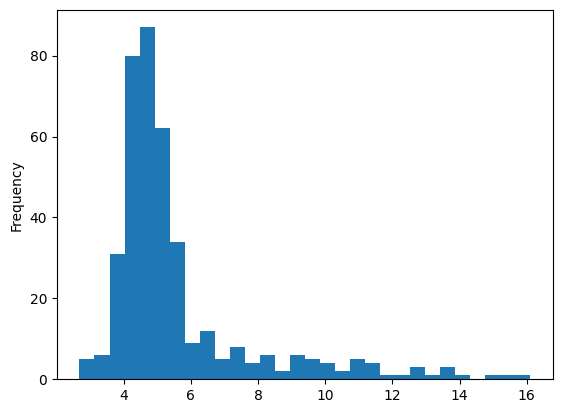

In [70]:
dataframe["glyhb"].plot(kind='hist', bins=30)   # robust scaler should work

# the target variable exibits a symmetrical distribution around 4.5 of glyhb
# a long code at high glyhb is present, representing the dyabetic patients

<Axes: ylabel='Frequency'>

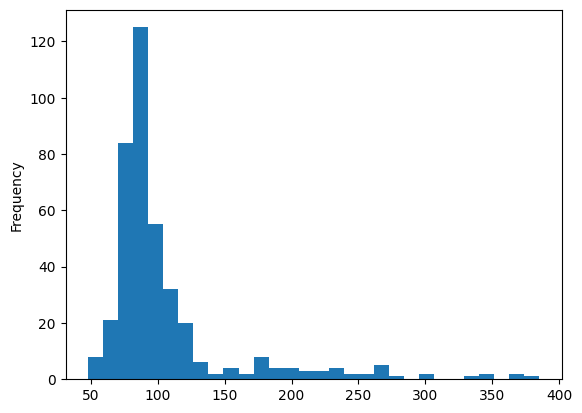

In [71]:
dataframe["stab.glu"].plot(kind='hist', bins=30)   # robust scaler should work

/tmp/ipykernel_3452/2296241822.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataframe.groupby("frame")["chol"].count().plot(kind='bar') # one-hot enconding or ordinal encoding


<Axes: xlabel='frame'>

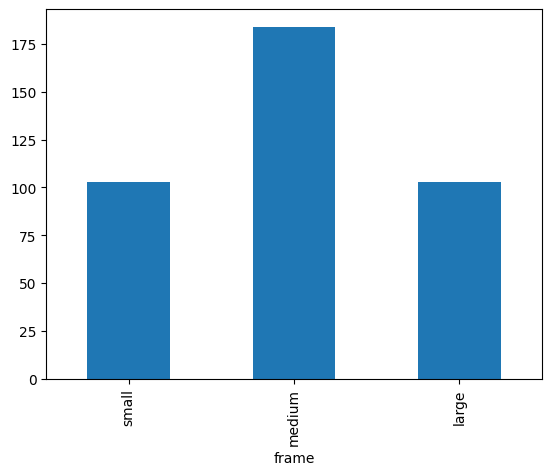

In [72]:
dataframe.groupby("frame")["chol"].count().plot(kind='bar') # one-hot enconding or ordinal encoding

<Axes: ylabel='Frequency'>

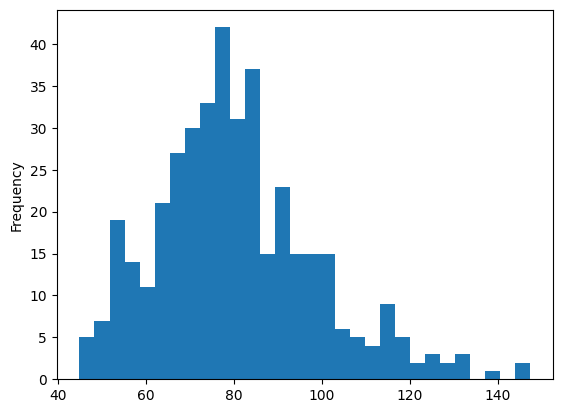

In [73]:
dataframe["weight"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option

<Axes: ylabel='Frequency'>

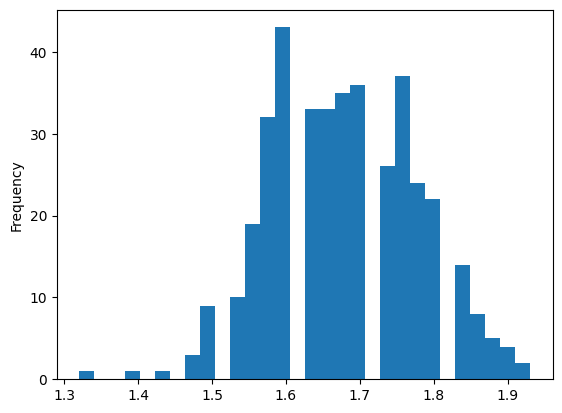

In [74]:
dataframe["height"].plot(kind='hist', bins=30) # standard scaler may be the better scaling option

<Axes: ylabel='Frequency'>

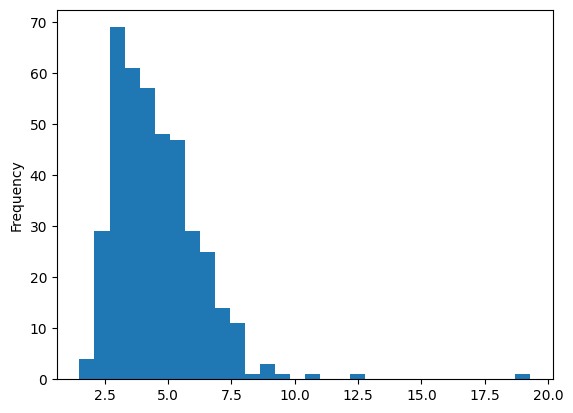

In [75]:
#dataframe["chol"].plot(kind='hist', bins=30) # standard scaler may be the better scaling option
dataframe["ratio"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option
# dataframe["hdl"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option

<Axes: ylabel='Frequency'>

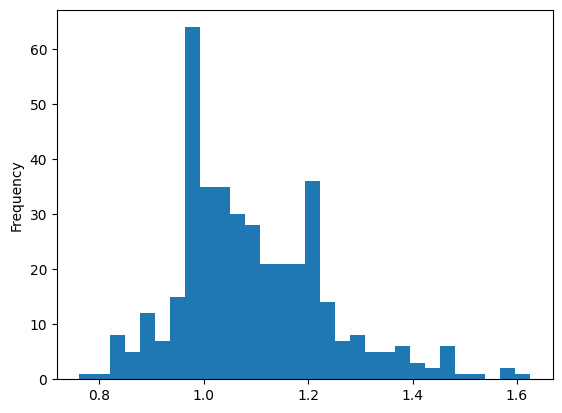

In [76]:
# dataframe["waist"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option
dataframe["hip"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option

<Axes: ylabel='Frequency'>

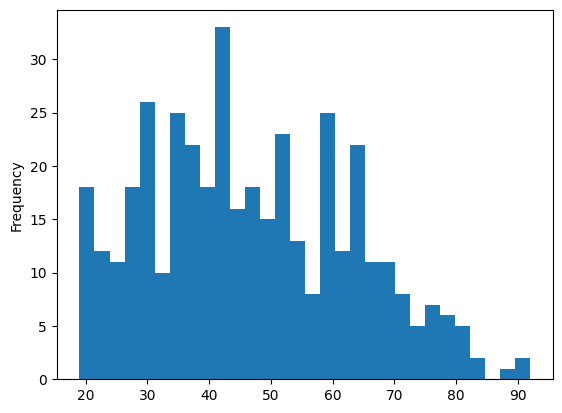

In [77]:
dataframe["age"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option

<Axes: ylabel='Frequency'>

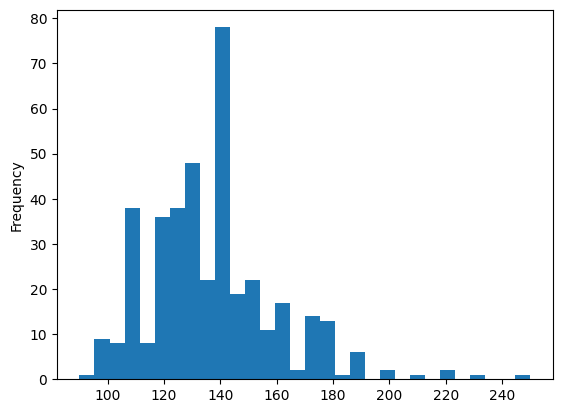

In [78]:
dataframe["bp.1s"].plot(kind='hist', bins=30) # robust scaler may be the better scaling option

<Axes: xlabel='gender', ylabel='glyhb'>

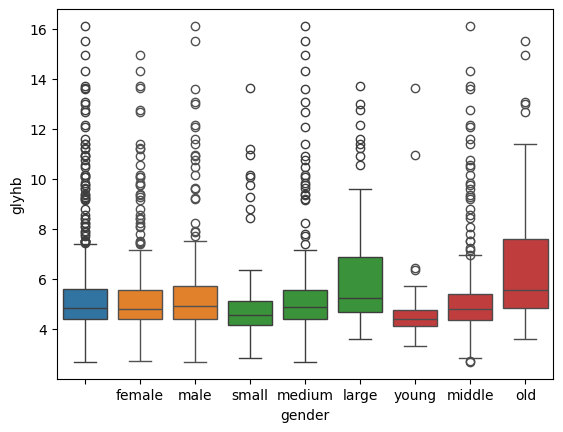

In [79]:
sns.boxplot(data=dataframe["glyhb"])
sns.boxplot(x="gender", y="glyhb", data=dataframe)
sns.boxplot(x="frame", y="glyhb", data=dataframe)
sns.boxplot(x="age_group", y="glyhb", data=dataframe)

# every subset in the boxplot shows a large number of outlayer in the high value range
# as expected, patients with large frame have higher values of glyhb
# same as old patients

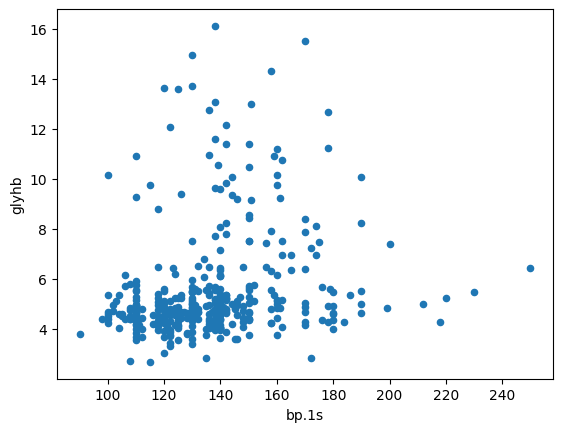

In [80]:
# dataframe.plot.scatter(x="map", y="glyhb")
dataframe.plot.scatter(x="bp.1s", y="glyhb")
plt.show()
# no strongly visible structures inside the scatter plot

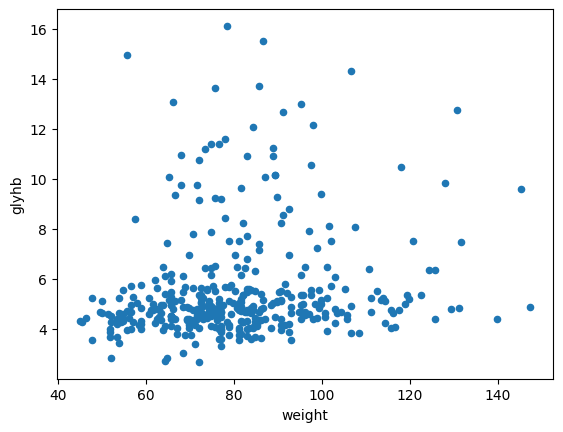

In [81]:
# dataframe.plot.scatter(x="absi", y="glyhb")
#dataframe.plot.scatter(x="height", y="glyhb")
dataframe.plot.scatter(x="weight", y="glyhb")
# dataframe.plot.scatter(x="hip", y="glyhb")
# dataframe.plot.scatter(x="waist", y="glyhb")
plt.show()
# no strongly visible structures inside the scatter plot

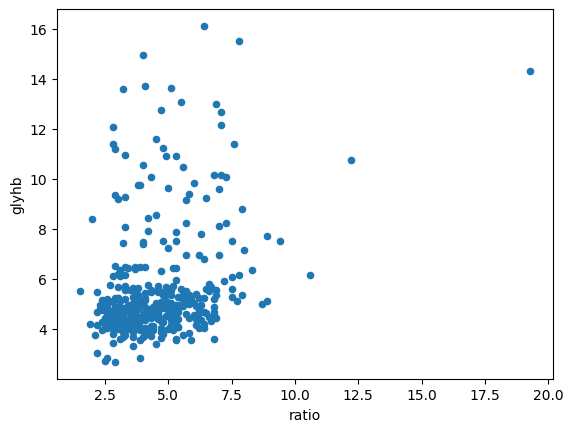

In [82]:
dataframe.plot.scatter(x="ratio", y="glyhb")
#dataframe.plot.scatter(x="hdl", y="glyhb")
#dataframe.plot.scatter(x="chol", y="glyhb")
plt.show()

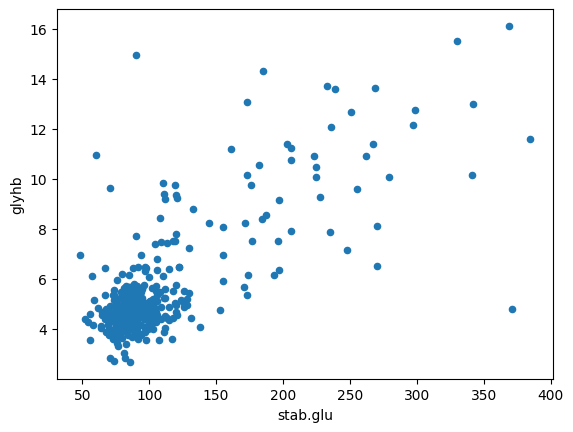

In [83]:
dataframe.plot.scatter(x="stab.glu", y="glyhb")
plt.show()

# clear dependence

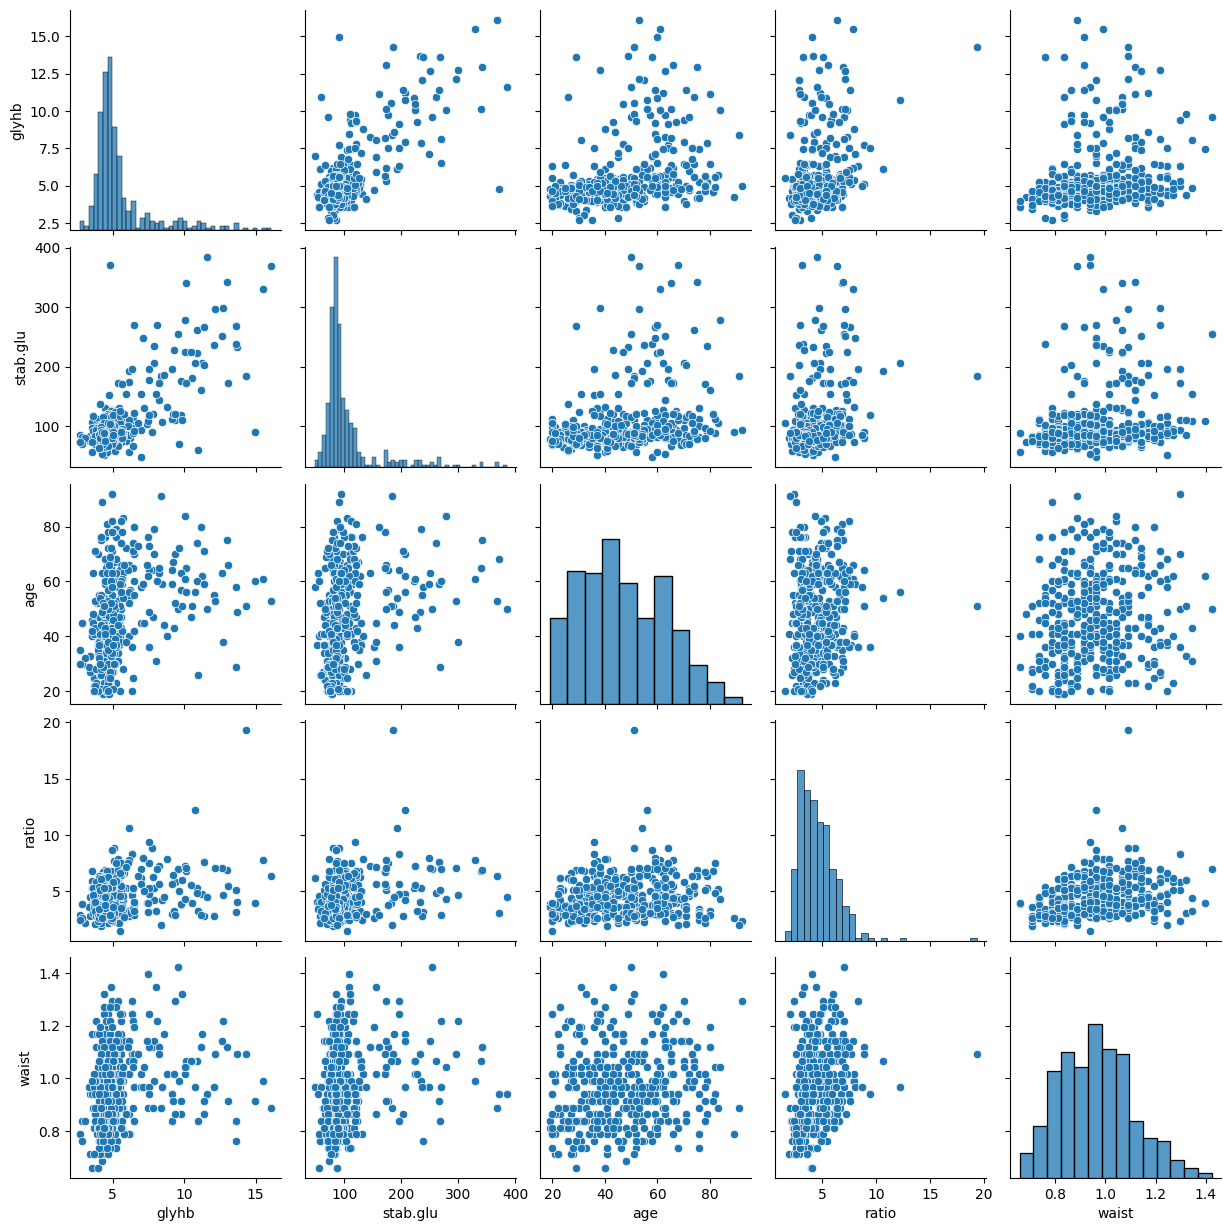

In [84]:
sns.pairplot(
    dataframe[
        ["glyhb",
         "stab.glu",
         "age",
         "ratio",
         "waist"]
    ]
)

# target variable glyhb
# clear dependece with glycemia
# a small dependece with age (already seen with age_group) is also visible

Text(0.5, 1.0, 'Glyhb Distribution for Males')

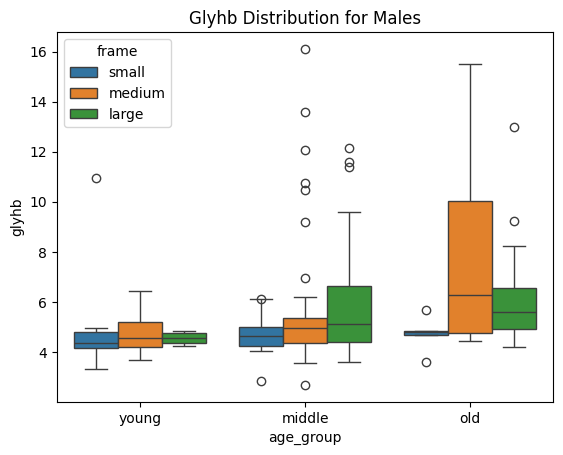

In [85]:
sns.boxplot(x="age_group", hue='frame', y="glyhb", data=dataframe[dataframe["gender"]=="male"])
plt.title('Glyhb Distribution for Males')
# from the graph, it becomes clear that:
# 1- older people has general higher glyhb.
#    It is clear that old people with small frame exibit better values of glyhb
# 2- middle aged people with a large frame present a great dispersion
#    and generally higher glyhb values compared to the other two categories
# 3- young people present the better values of glyhb and the smallest dispersion

# finally: old people with large and medium frame + middle aged people with
# large frame exibit high glyhb values, indicating pre-diabetes or diabetes

Text(0.5, 1.0, 'Glyhb Distribution for Females')

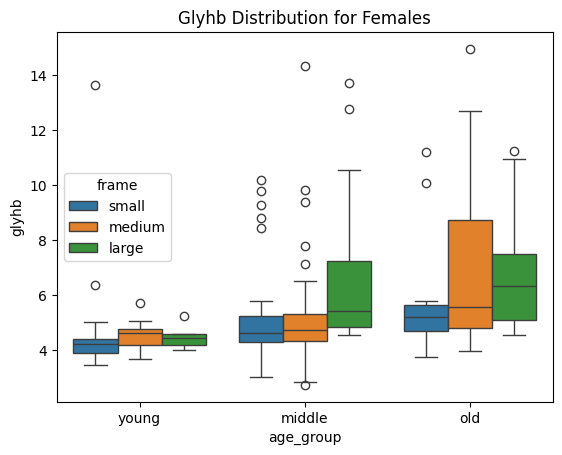

In [86]:
sns.boxplot(x="age_group", hue='frame', y="glyhb", data=dataframe[dataframe["gender"]=="female"])
plt.title('Glyhb Distribution for Females')

# for females, it doesn't change so much

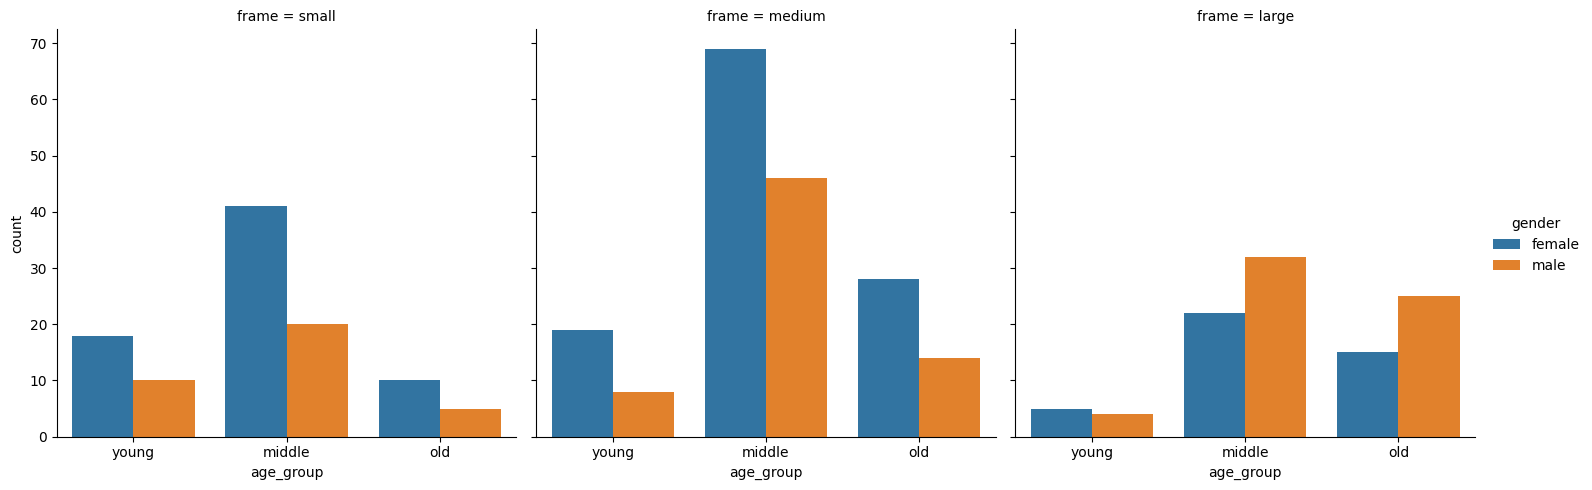

In [87]:
sns.catplot(data=dataframe, x='age_group', hue='gender', col='frame', kind='count')
plt.show()

# dataframe["frame"].value_counts()
# dataframe["gender"].value_counts()
# dataframe["age_group"].value_counts()

# the major amount of patients has a medium frame. Anyway, how has it been calculated?
# the bmi feature may represent a better parameter (and continuous)
# more female than male
# a lot of middle-aged people, not so many old and young

<Axes: xlabel='gender', ylabel='stab.glu'>

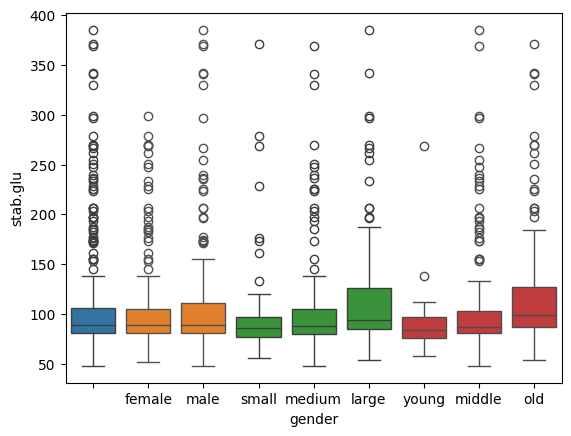

In [88]:
# dataframe["stab.glu"].plot(kind='hist', bins=30)
# very similar distribution to that of glyhb

sns.boxplot(data=dataframe["stab.glu"])
sns.boxplot(x="gender", y="stab.glu", data=dataframe)
sns.boxplot(x="frame", y="stab.glu", data=dataframe)
sns.boxplot(x="age_group", y="stab.glu", data=dataframe)

# old patients and large patients exibit higher values of glycemia

<Axes: xlabel='gender', ylabel='age'>

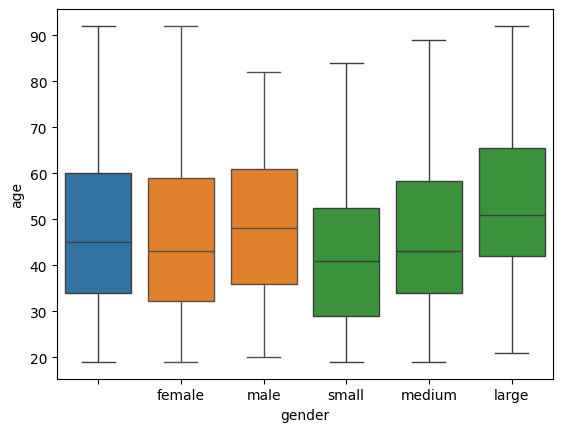

In [89]:
#dataframe["age"].plot(kind='hist', bins=20)

sns.boxplot(data=dataframe["age"])
sns.boxplot(x="gender", y="age", data=dataframe)
sns.boxplot(x="frame", y="age", data=dataframe)

# AGE: irregular distribution, with mean set at ~ 45 years
# there a moderate skewness on the right
# it seems that older patients have larger frame

<Axes: xlabel='gender', ylabel='ratio'>

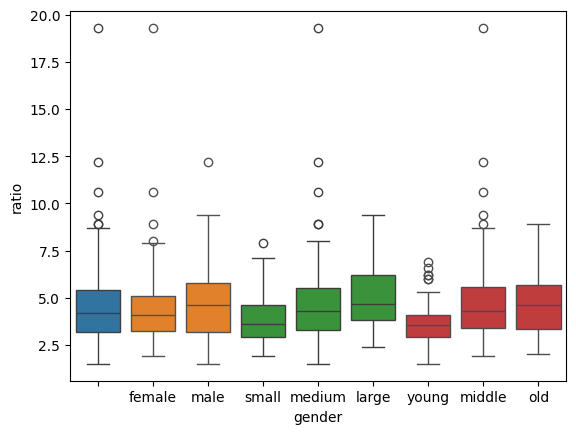

In [90]:
# dataframe["ratio"].plot(kind='hist', bins=30)
# ratio between total cholesterole and HDL
# strong skewness on the right and visible outliers at very high values

sns.boxplot(data=dataframe["ratio"])
sns.boxplot(x="gender", y="ratio", data=dataframe)
sns.boxplot(x="frame", y="ratio", data=dataframe)
sns.boxplot(x="age_group", y="ratio", data=dataframe)

# dataframe[dataframe["ratio"]> 8.5]
# we can see that glyhb is usually high for these outlayers

# as expected, small and young patients have better chol/hdl values than large and old patients
# male patients exibit worse ratio values than female

In [91]:
# dataframe["absi"].plot(kind='hist', bins=20)
# bmi has mean at about 27. It presents a skewness at higher values
# absi instead seems more symmetric with a little skewness

'''
sns.boxplot(data=dataframe["absi"])
sns.boxplot(x="gender", y="absi", data=dataframe)
sns.boxplot(x="age_group", y="absi", data=dataframe)
sns.boxplot(x="frame", y="absi", data=dataframe)
'''

# larger variance in bmi for young patients
# female exibit worse bmi values than male

# instead, absi in much worse for old patients
# absi is instead worse for male
# absi doesn't change so much between the three frame classes

'\nsns.boxplot(data=dataframe["absi"])\nsns.boxplot(x="gender", y="absi", data=dataframe)\nsns.boxplot(x="age_group", y="absi", data=dataframe)\nsns.boxplot(x="frame", y="absi", data=dataframe)\n'

In [92]:
# dataframe["map"].plot(kind='hist', bins=20)
# map has mean at about 100. It presents a skewness at higher values

'''
sns.boxplot(data=dataframe["map"])
sns.boxplot(x="gender", y="map", data=dataframe)
sns.boxplot(x="frame", y="map", data=dataframe)
sns.boxplot(x="age_group", y="map", data=dataframe)
'''

# worse MAP values as age increase
# better values are obtained by small and young patients

'\nsns.boxplot(data=dataframe["map"])\nsns.boxplot(x="gender", y="map", data=dataframe)\nsns.boxplot(x="frame", y="map", data=dataframe)\nsns.boxplot(x="age_group", y="map", data=dataframe)\n'

Analysis of Outliers (diabetic)

In [93]:
 # We already know from the previous analysis that outliers in the glyhb distribution are diabetic or pre-diabetic patients
 # we divide the dataset with labels in order to focus on diabetic/outliers entries

dataframe["diabetes"] = pd.cut(
    dataframe["glyhb"],
    bins=[0, 5.7, 6.5, float("inf")],
    labels=["healty", "pre_d", "diabetic"],
    right=False
)

dataframe

,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn,age_group,diabetes
id,,,,,,,,,,,,,,,,,,,,
1000,203.0,82,56.0,3.6,4.310000,Buckingham,46,female,1.5748,54.884632,medium,118.0,59.0,NaN,NaN,0.7366,0.9652,720.0,middle,healty
1001,165.0,97,24.0,6.9,4.440000,Buckingham,29,female,1.6256,98.883056,large,112.0,68.0,NaN,NaN,1.1684,1.2192,360.0,young,healty
1002,228.0,92,37.0,6.2,4.640000,Buckingham,58,female,1.5494,116.119552,large,190.0,92.0,185.0,92.0,1.2446,1.4478,180.0,middle,healty
1003,78.0,93,12.0,6.5,4.630000,Buckingham,67,male,1.7018,53.977448,large,110.0,50.0,NaN,NaN,0.8382,0.9652,480.0,old,healty
1005,249.0,90,28.0,8.9,7.720000,Buckingham,64,male,1.7272,83.007336,medium,138.0,80.0,NaN,NaN,1.1176,1.0414,300.0,old,diabetic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41506,296.0,369,46.0,6.4,16.110001,Louisa,53,male,1.7526,78.471416,medium,138.0,94.0,130.0,94.0,0.8890,0.9906,210.0,middle,diabetic
41507,284.0,89,54.0,5.3,4.390000,Louisa,51,female,1.6002,69.853168,medium,140.0,100.0,146.0,102.0,0.8128,1.0922,180.0,middle,healty
41510,194.0,269,38.0,5.1,13.630000,Louisa,29,female,1.7526,75.749864,small,120.0,70.0,NaN,NaN,0.8382,1.0160,20.0,young,diabetic


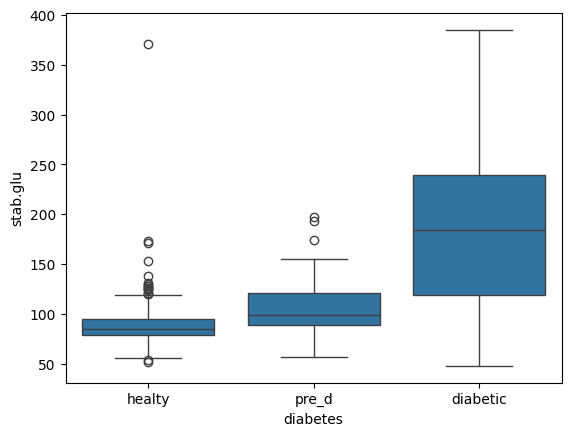

In [121]:
sns.boxplot(data=dataframe, x="diabetes", y="stab.glu")
plt.savefig(folder +"images/EDA_glycemia_boxplot.png", format='png')
# as expected, glycemia is the main actor into diabetes prediction

<Axes: xlabel='diabetes', ylabel='ratio'>

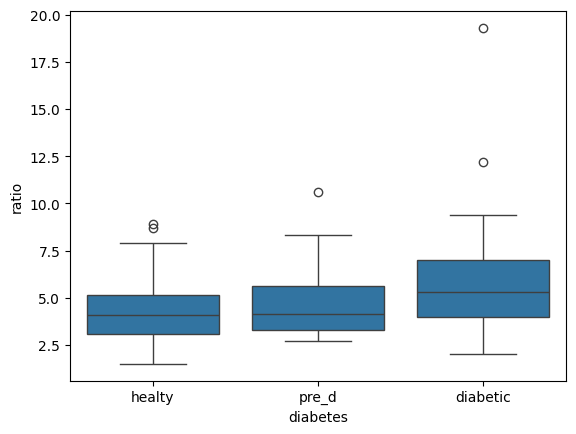

In [95]:
sns.boxplot(data=dataframe, x="diabetes", y="ratio")
#sns.boxplot(data=dataframe, x="diabetes", y="chol")

# diabetic people exibit higher total cholesterol level and generally worse ratio of tot-Chol/HDL

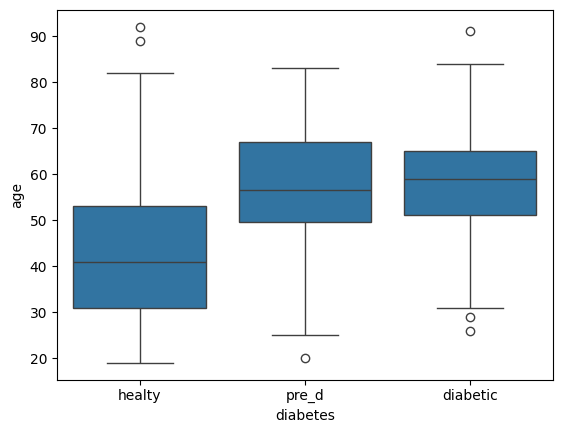

In [119]:
sns.boxplot(data=dataframe, x="diabetes", y="age")
plt.savefig(folder +"images/EDA_age_boxplot.png", format='png')
# as already stated, age represent a key paramenter

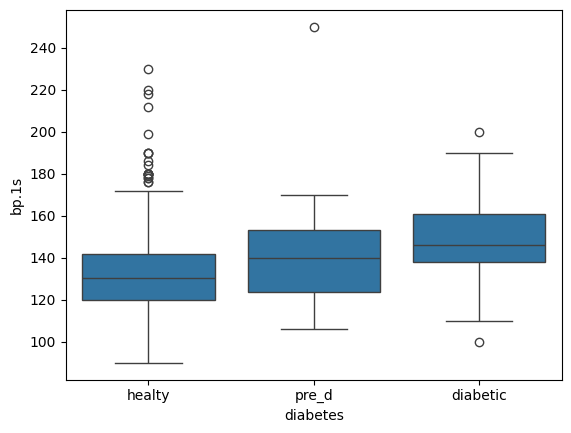

In [120]:
sns.boxplot(data=dataframe, x="diabetes", y="bp.1s")
plt.savefig(folder +"images/EDA_pressure_boxplot.png", format='png')
#sns.boxplot(data=dataframe, x="diabetes", y="map")
#sns.boxplot(data=dataframe, x="diabetes", y="bp.1d")

# sistolic blood pressure exibits a stronger correlation with diabetes

<Axes: xlabel='diabetes', ylabel='waist'>

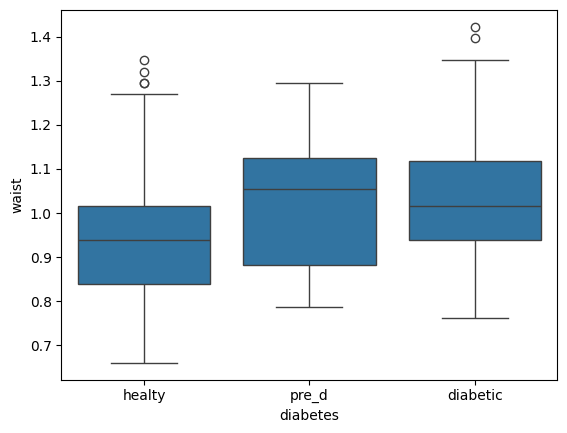

In [98]:
sns.boxplot(data=dataframe, x="diabetes", y="waist")
# sns.boxplot(data=dataframe, x="diabetes", y="absi")
#sns.boxplot(data=dataframe, x="diabetes", y="hip")

# stronger correlation are visible using the waist variable

<Axes: xlabel='frame', ylabel='weight'>

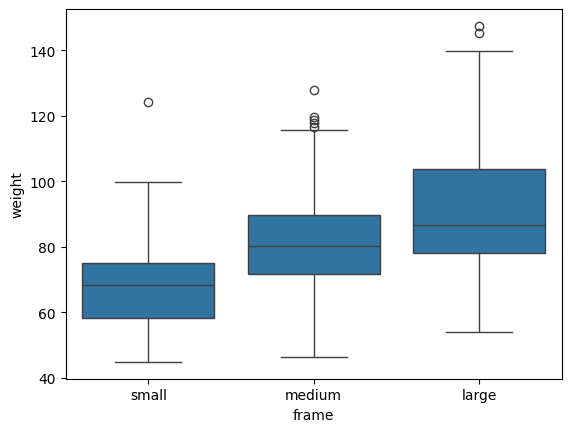

In [99]:
sns.boxplot(x="frame", y="weight",data=dataframe)
#sns.boxplot(x="frame", y="waist",data=dataframe)
#sns.boxplot(x="frame", y="hip",data=dataframe)

# one can notice that the frame variable seems to be strongly directly correlated to weight, waist and hip variables

In [100]:
dataframe.groupby("frame")[["weight", "waist", "hip"]].mean()

/tmp/ipykernel_3452/3882641130.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dataframe.groupby("frame")[["weight", "waist", "hip"]].mean()


,weight,waist,hip
frame,,,
small,68.474946,0.864821,1.010383
medium,80.880659,0.962424,1.101361
large,92.444692,1.062318,1.161676


CORRELATION MATRIX

In [101]:
frame_map = {
    "small": 0.0,
    "medium": 1.0,
    "large": 2.0
}

dataframe["frame_ord"] = dataframe["frame"].map(frame_map).astype(float)

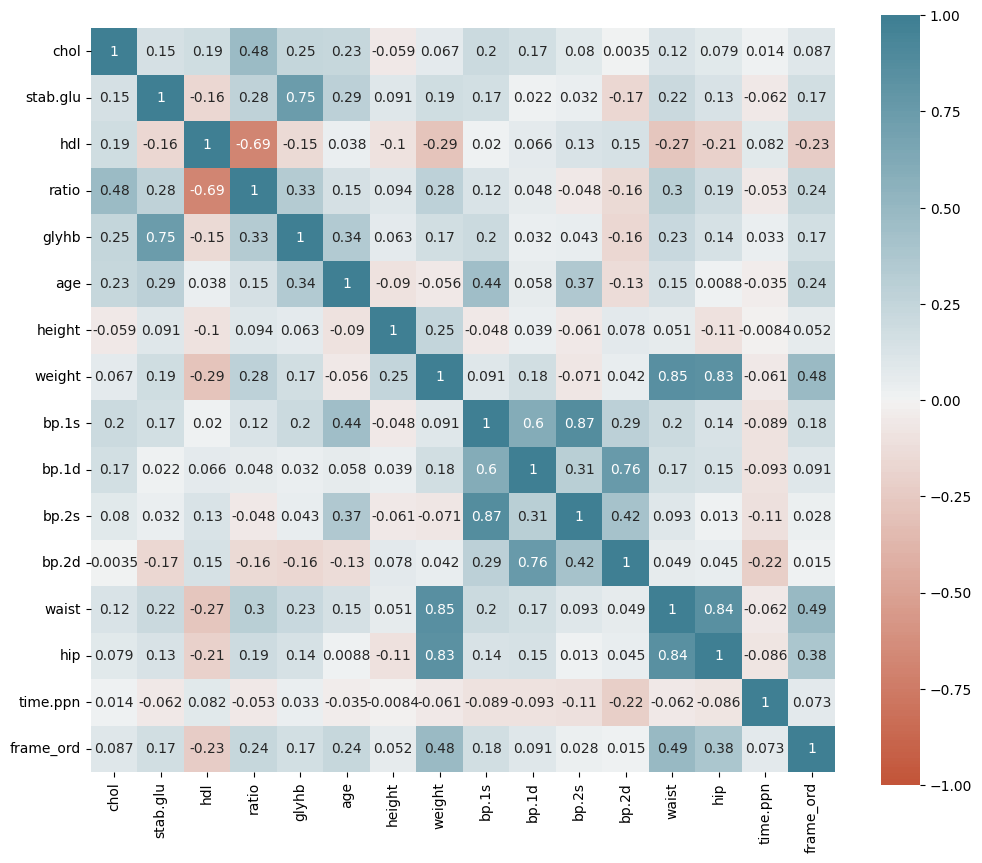

In [102]:
corrMatrix = dataframe.select_dtypes(include=[np.number]).corr() # only numerical variables

plt.figure(figsize=(12,10))
sns.heatmap(corrMatrix,  vmin=-1, vmax = 1, center = 0,
            cmap = sns.diverging_palette(20,220, n=200),
            annot=True, square = True)
plt.show()

The ordinal variable frame shows its strongest positive associations with weight, waist and hip. This suggests that body frame primarily reflects overall body size, although the moderate correlation values indicate that it also captures information not entirely explained by anthropometric measurements

In [103]:
corrMatrix["glyhb"].abs().sort_values(ascending=False)

,glyhb
glyhb,1.000000
stab.glu,0.749236
age,0.338929
ratio,0.328665
chol,0.247099
waist,0.226184
bp.1s,0.197936
weight,0.171882
frame_ord,0.171866
bp.2d,0.160241


Glycated haemoglobin is strongly correlated to glycemia. Anyway, other parameters play a key role: age, chol ratio, chol and waist.

In [104]:
corr_df = corrMatrix.stack().reset_index()
corr_df.columns = ["feature_1", "feature_2", "abs_corr"]
corr_df["abs_corr"] = corr_df["abs_corr"].abs()
corr_df.sort_values(by='abs_corr', ascending = False, inplace = True)
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2'] ] # drop 1 values

new_corr_df = corr_df.copy().reset_index(drop=True)
k = 0
for i in range(corr_df.shape[0]):
  if i==0:
    continue
  if corr_df['feature_1'].iloc[i] == corr_df['feature_2'].iloc[i-1]:
    new_corr_df = new_corr_df.drop(index=i)
corr_df = new_corr_df.reset_index(drop=True)
corr_df.head(30)

,feature_1,feature_2,abs_corr
0,bp.2s,bp.1s,0.868773
1,weight,waist,0.849855
2,waist,hip,0.837080
3,hip,weight,0.829115
4,bp.1d,bp.2d,0.757062
5,stab.glu,glyhb,0.749236
6,hdl,ratio,0.686907
7,bp.1d,bp.1s,0.596557
8,waist,frame_ord,0.490969
9,weight,frame_ord,0.476665


It becomes clear that waist, hip, weight, are strongly correlated with each others.
Moreover, the blood pressures are strongly correlated with each other and obviously with MAP. The cholesterol ratio is obviously correted with chol values. Also absi and blood pressure are correlated with age.



Analysis of NaN values

In [105]:
dataframe.isna().sum()
# 13 values have the target variable null. I guess they should be deleted.
# A large number of values in the bp.2s and bp.2d columns are null. ->
# These represent just the second check of blood pressure. I believe it doesn't represent a key parameter.
# Some values in "frame" are null. we should use an imputer

,0
chol,1
stab.glu,0
hdl,1
ratio,1
glyhb,13
location,0
age,0
gender,0
height,5
weight,1


In [106]:
dataframe = dataframe.drop(columns=["bp.2s", "bp.2d", "age_group", "time.ppn", "location", "frame_ord"],
                           errors="ignore")    #  "map", "absi"
# Some variables are not key in order to investigate nan values. I remove them
# I also deleted the derived features
# moreover, the second check of blood pressure is not so relevant, moreover it has a lot of NaN values.
# I guess we should just remove it

In [107]:
dataframe.isna().sum()

,0
chol,1
stab.glu,0
hdl,1
ratio,1
glyhb,13
age,0
gender,0
height,5
weight,1
frame,12


In [108]:
nan_df = dataframe[dataframe.isna().any(axis=1)]
print(f"Number of rows with NaN values: {nan_df.shape[0]}")

good_df = dataframe[dataframe.notna().all(axis=1)]

Number of rows with NaN values: 36


In [109]:
display( nan_df[nan_df["glyhb"].isna()] )
# these entries are all good patient (only in terms of glicemy)
# they may be just eliminated

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
1326,262.0,84,38.0,6.9,NaN,43,male,1.9050,114.758776,large,124.0,80.0,1.0922,1.2446,NaN
2774,218.0,88,39.0,5.6,NaN,44,female,1.6764,86.636072,large,138.0,79.0,1.0160,1.1430,NaN
2784,234.0,80,63.0,3.7,NaN,31,male,1.7780,74.842680,medium,121.0,71.0,0.8890,0.9906,NaN
4808,218.0,80,71.0,3.1,NaN,68,male,1.7780,77.110640,large,130.0,73.0,0.9398,1.0668,NaN
4826,231.0,105,61.0,3.8,NaN,58,female,1.6002,104.326160,large,141.0,99.0,0.9906,1.2192,NaN
4827,217.0,78,48.0,4.5,NaN,53,female,1.6002,71.667536,medium,139.0,79.0,0.8382,1.0160,NaN
15542,205.0,88,41.0,5.0,NaN,57,male,1.6764,77.564232,medium,132.0,82.0,0.9398,1.0160,NaN
15813,237.0,96,52.0,4.6,NaN,45,male,1.7526,58.966960,small,137.0,74.0,0.8382,0.8890,NaN
20258,226.0,68,83.0,2.7,NaN,49,female,1.6002,58.059776,small,121.0,75.0,0.7874,0.9144,NaN


In [110]:
display(nan_df[nan_df["chol"].isna()])
# we may use a KNN imputer in preprocessing

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
1281,NaN,74,NaN,NaN,4.28,48,male,1.7272,45.3592,small,120.0,85.0,0.6858,0.8382,healty


In [111]:
display( nan_df[nan_df[["bp.1s", "bp.1d"]].isna().any(axis=1)] )
# simple imputer

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
1015,227.0,75,44.0,5.2,3.94,37,male,1.4986,77.110640,medium,NaN,NaN,0.8636,0.9906,healty
1031,183.0,79,46.0,4.0,4.59,40,female,1.4986,74.842680,medium,NaN,NaN,0.9398,1.0922,healty
1314,190.0,107,32.0,5.9,3.56,46,male,1.8288,92.986360,medium,NaN,NaN,1.1684,1.2446,healty
2780,145.0,85,29.0,5.0,3.99,38,female,NaN,56.699000,NaN,NaN,NaN,0.7874,0.8890,healty
15805,197.0,92,46.0,4.3,4.75,36,female,1.6256,61.688512,small,NaN,NaN,0.8128,0.9398,healty


In [112]:
display( nan_df[nan_df["hip"].isna()]  ) # / waist
# two healty sample. We can remove them or impute the value

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
21321,158.0,74,64.0,2.5,2.73,30,female,1.5748,64.410064,medium,108.0,68.0,NaN,NaN,healty
41253,192.0,85,69.0,2.8,4.38,51,male,1.6510,66.224432,large,130.0,110.0,NaN,NaN,healty


In [113]:
nan_df[nan_df["frame"].isna()]
# frame can be imputed
# we can use a KNN Imputer with scikit-learn

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
2754,196.0,82,58.0,3.4,4.25,76,male,1.6510,69.853168,NaN,158.0,78.0,0.9398,1.0414,healty
2780,145.0,85,29.0,5.0,3.99,38,female,NaN,56.699000,NaN,NaN,NaN,0.7874,0.8890,healty
2794,232.0,184,114.0,2.0,8.40,91,female,1.5494,57.606184,NaN,170.0,82.0,0.8890,0.9652,diabetic
4805,292.0,235,55.0,5.3,7.87,79,male,1.7780,74.842680,NaN,170.0,90.0,0.9906,1.0414,diabetic
4813,244.0,101,36.0,6.8,4.66,32,male,1.7780,96.161504,NaN,132.0,90.0,0.9906,1.1176,healty
13500,255.0,112,34.0,7.5,5.60,82,male,1.6764,73.935496,NaN,179.0,89.0,0.9398,1.0922,healty
15827,205.0,83,42.0,4.9,4.87,72,female,1.5494,81.646560,NaN,170.0,90.0,0.9906,1.1938,healty
20279,147.0,78,42.0,3.5,4.67,23,female,1.5494,83.914520,NaN,127.0,71.0,1.0922,1.1938,healty
20790,203.0,104,36.0,5.6,NaN,41,male,1.8034,95.254320,NaN,140.0,112.0,0.9398,1.0668,NaN


In [114]:
nan_df[nan_df["height"].isna()]
# knn imputer

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
2780,145.0,85,29.0,5.0,3.99,38,female,NaN,56.69900,NaN,NaN,NaN,0.7874,0.8890,healty
4760,218.0,182,54.0,4.0,10.55,51,female,NaN,97.52228,large,139.0,69.0,1.0668,1.3462,diabetic
15757,173.0,83,37.0,4.7,4.31,40,female,NaN,58.96696,small,122.0,76.0,0.9398,0.9652,healty
16016,214.0,87,35.0,6.1,5.38,44,female,NaN,86.18248,large,140.0,75.0,0.9652,1.1176,healty
20762,300.0,65,59.0,5.1,4.56,34,female,NaN,72.57472,small,120.0,60.0,1.0160,1.1938,healty


In [115]:
nan_df[nan_df["weight"].isna()]
# knn imputer

,chol,stab.glu,hdl,ratio,glyhb,age,gender,height,weight,frame,bp.1s,bp.1d,waist,hip,diabetes
id,,,,,,,,,,,,,,,
15012,115.0,239,36.0,3.2,13.6,58,male,1.7526,NaN,medium,125.0,69.0,0.762,0.9398,diabetic


In [116]:
"""
# si potrebbero ora fare grafici su i valori nan e la loro distribuzione
"""

'\n# si potrebbero ora fare grafici su i valori nan e la loro distribuzione\n'